# Traffic Accident Data Analysis

In [156]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [157]:
# Importing the dataset
accident_data = pd.read_csv("RTA_dataset.csv")

# Cleaning the dataset
accident_data.fillna("Unknown", inplace=True)
accident_data.drop(columns=['Defect_of_vehicle', 'Service_year_of_vehicle', 'Fitness_of_casuality'], inplace=True)

/var/folders/rl/7hy25gqj1fndpbst4q81djph0000gn/T/ipykernel_1614/4226802497.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  accident_data["Time"] = pd.to_datetime(accident_data["Time"])


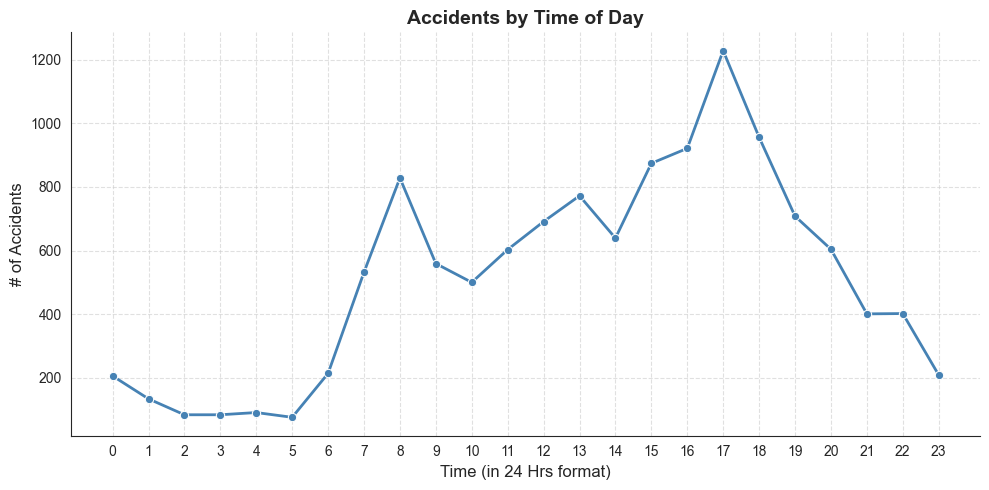

In [158]:
# Accidents by time of day

accident_data["Time"] = pd.to_datetime(accident_data["Time"])
accident_data["Hours"] = accident_data["Time"].dt.hour

hours_count = accident_data['Hours'].value_counts().sort_index()


plt.figure(figsize=(10, 5))
sns.lineplot(data=hours_count, marker='o', linewidth=2, color="steelblue")
sns.despine()

plt.xticks(range(0, 24))
plt.title("Accidents by Time of Day", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.6, linestyle="--")
plt.xlabel("Time (in 24 Hrs format)", fontsize=12)
plt.ylabel("# of Accidents", fontsize=12)
plt.tight_layout()

plt.savefig("outputs/time_of_day.png", dpi=300, bbox_inches='tight')
plt.show()


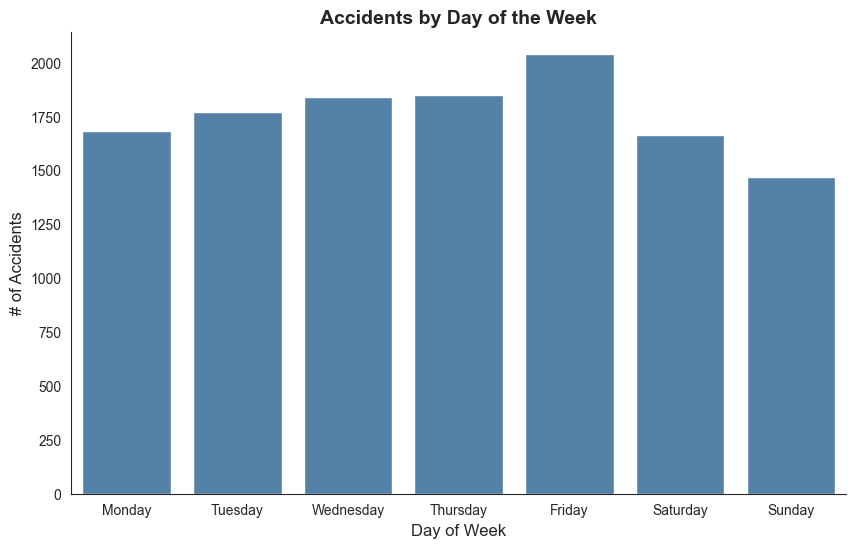

In [159]:
# Accidents by day of week
days_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
accident_data["Day_of_week"] = pd.Categorical(accident_data["Day_of_week"], categories =days_of_week, ordered=True )

ordered_days = accident_data["Day_of_week"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=ordered_days, color="steelblue")
sns.despine()

plt.title("Accidents by Day of the Week", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("# of Accidents", fontsize=12)

plt.savefig("outputs/day_of_week.png", dpi=300, bbox_inches='tight')
plt.show()


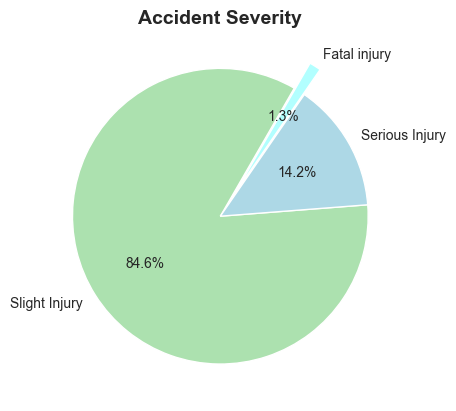

In [160]:
# Severity of accident
severity = accident_data["Accident_severity"].value_counts()
colors = ["#ACE1AF", "#ADD8E6", "#B2FFFF"]
plt.pie(severity, labels=severity.index, autopct="%1.1f%%", colors=colors, explode=[0, 0, 0.2], startangle=60)

plt.title("Accident Severity", fontsize=14, fontweight='bold')

plt.savefig("outputs/accident_severity.png", dpi=300, bbox_inches='tight')
plt.show()